In [135]:
# to autoimport edited modules in the notebook
%load_ext autoreload
%autoreload 2

from grsc_cb_model import GRSC_CB_Model
from grsc_cb_instance import GRSC_CB_Instance
import numpy as np
from scipy.spatial import Delaunay
import networkx as nx

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<unknown>:7: SyntaxWarning: invalid escape sequence '\S'
<unknown>:4: SyntaxWarning: invalid escape sequence '\S'


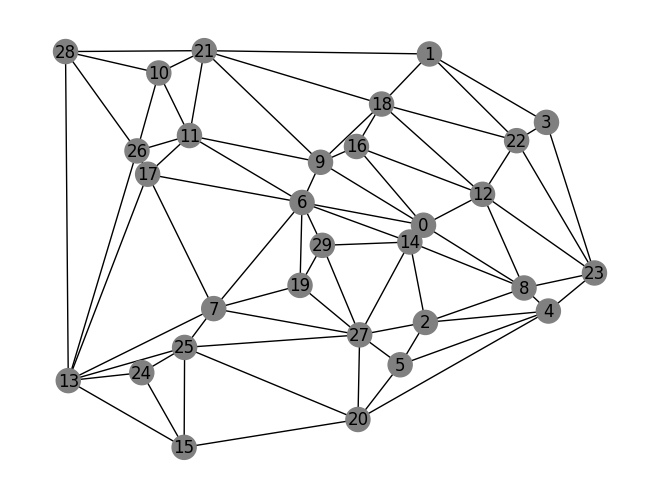

In [136]:
# generate a random instance of 8 land parcels
points = np.random.rand(30, 2)
tri = Delaunay(points)

G = nx.Graph()
G.add_nodes_from(range(len(points)))

# for each node, it connects it to its neighbors using Delaunay triangulation
for simplex in tri.simplices:
    i, j, k = simplex
    G.add_edge(i, j)
    G.add_edge(j, k)
    G.add_edge(i, k)

# toy instance
instance = GRSC_CB_Instance(V=G.nodes, 
                            E=G.edges,
                            pos=points, 
                            S_1=list(range(6)), 
                            S_2=list(range(6, 12)), 
                            P_1=3, 
                            P_2=3, 
                            k=3, 
                            w={(i, s): 1.5 if s < 6 and i < 2 else 0.5 if s < 6 and i >= 2 else 2 if s >= 6 and i < 2 else 1.8 for i in G.nodes for s in range(12)}, 
                            lambda_s={s: 3 if s < 6 else 5 for s in range(12)}, 
                            c={i: 1 if i < 3 else 2 for i in G.nodes})

instance.draw_graph()


Status: 2
Objective: 17.0
Nodes in the reserve (x): [1, 3, 9, 12, 16, 18, 21, 22, 23]
Nodes in the core (z): [1, 3, 18, 22]
Species protected (u): [0, 3, 4, 5, 7, 8, 9, 10, 11]


AttributeError: 'GRSC_CB_Instance' object has no attribute 'draw_solution_summary'

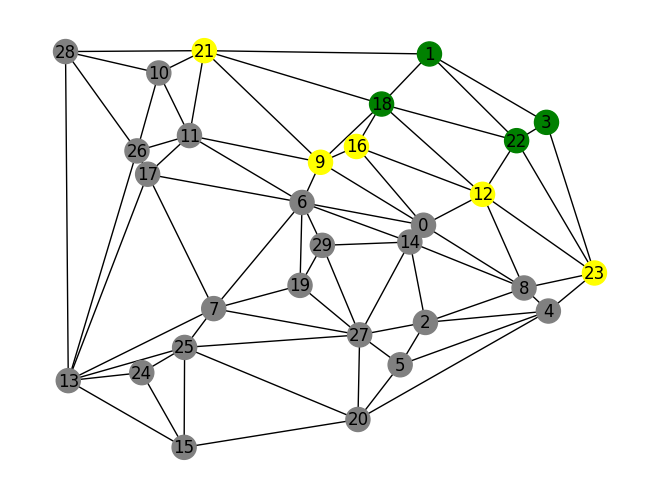

In [ ]:
model = GRSC_CB_Model(instance)
model.solve()
model.print_solution()
model.print_graph()